# Task 8: Customer Segmentation with Actionable Business Insights

This notebook builds a full customer segmentation solution for an e-commerce company using **K-Means clustering** as the core technique, supported by **regression** (predicting customer rating), **classification** (predicting purchase likelihood), and **hyperparameter tuning**.

**Workflow:**
1. Exploratory Data Analysis
2. Data Preprocessing (missing values, outliers, scaling, RFM features)
3. K-Means Clustering (elbow method + silhouette score to choose k)
4. Segment Profiling (business names + characteristics)
5. Regression: predict `CustomerRating`
6. Classification: predict `WillPurchaseAgain`
7. Hyperparameter Tuning (GridSearchCV)
8. Business Insights & Recommendations


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              classification_report, confusion_matrix, roc_auc_score,
                              ConfusionMatrixDisplay, RocCurveDisplay)

pd.set_option('display.max_columns', None)
np.random.seed(42)


## 2. Load and Explore the Dataset

In [2]:
df = pd.read_csv('customer_data.csv')
print("Shape:", df.shape)
df.head()


Shape: (1200, 12)


,CustomerID,Age,Gender,AnnualIncome,TotalSpending,PurchaseFrequency,AverageOrderValue,DaysSinceLastPurchase,WebsiteVisits,DiscountUsage,CustomerRating,WillPurchaseAgain
0,20001,43,Female,61300,273.57,4,63.77,121,5.0,24.2,3.7,0
1,20002,29,Male,43506,1601.49,20,284.05,98,15.0,13.7,3.1,1
2,20003,54,Female,55377,3722.03,27,194.13,11,45.0,0.6,5.0,1
3,20004,24,Female,44157,622.56,2,190.70,12,27.0,12.7,4.2,1
4,20005,28,Male,80605,6069.94,29,380.22,11,36.0,4.2,4.8,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             1200 non-null   int64  
 1   Age                    1200 non-null   int64  
 2   Gender                 1200 non-null   str    
 3   AnnualIncome           1200 non-null   int64  
 4   TotalSpending          1200 non-null   float64
 5   PurchaseFrequency      1200 non-null   int64  
 6   AverageOrderValue      1185 non-null   float64
 7   DaysSinceLastPurchase  1200 non-null   int64  
 8   WebsiteVisits          1185 non-null   float64
 9   DiscountUsage          1200 non-null   float64
 10  CustomerRating         1185 non-null   float64
 11  WillPurchaseAgain      1200 non-null   int64  
dtypes: float64(5), int64(6), str(1)
memory usage: 112.6 KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe()


Missing values per column:
CustomerID                0
Age                       0
Gender                    0
AnnualIncome              0
TotalSpending             0
PurchaseFrequency         0
AverageOrderValue        15
DaysSinceLastPurchase     0
WebsiteVisits            15
DiscountUsage             0
CustomerRating           15
WillPurchaseAgain         0
dtype: int64

Duplicate rows: 0


,CustomerID,Age,AnnualIncome,TotalSpending,PurchaseFrequency,AverageOrderValue,DaysSinceLastPurchase,WebsiteVisits,DiscountUsage,CustomerRating,WillPurchaseAgain
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1185.000000,1200.000000,1185.000000,1200.000000,1185.000000,1200.000000
mean,20600.500000,36.846667,61284.806667,2331.695333,11.675000,159.020160,62.707500,20.985654,24.732667,3.754346,0.595833
std,346.554469,10.468977,18881.015123,2165.206116,9.181392,80.879009,61.906709,15.006439,20.485791,0.614383,0.490935
min,20001.000000,18.000000,18000.000000,102.120000,1.000000,40.400000,1.000000,1.000000,0.000000,2.500000,0.000000
25%,20300.750000,29.000000,47763.250000,673.772500,4.000000,96.280000,12.000000,8.000000,10.275000,3.300000,0.000000
50%,20600.500000,37.000000,61356.500000,1501.345000,9.000000,138.120000,25.500000,19.000000,18.000000,3.700000,1.000000
75%,20900.250000,44.000000,73834.750000,3484.975000,17.000000,205.400000,117.000000,31.000000,32.725000,4.200000,1.000000
max,21200.000000,70.000000,119413.000000,8996.480000,40.000000,397.810000,200.000000,60.000000,80.000000,5.000000,1.000000


### 2.1 Exploratory Visualizations

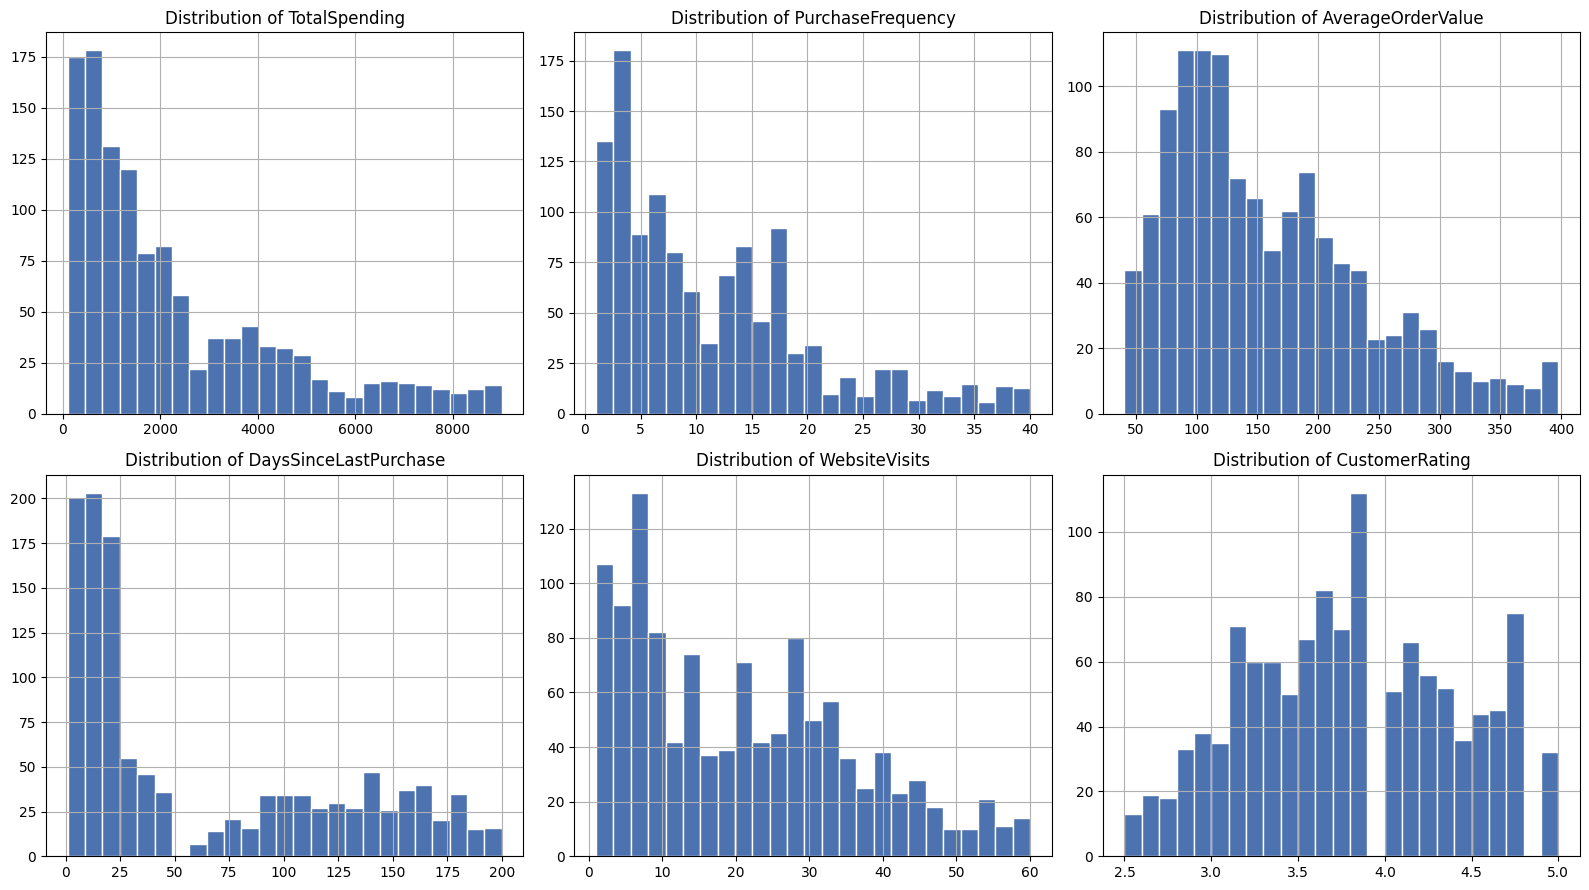

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cols_to_plot = ['TotalSpending', 'PurchaseFrequency', 'AverageOrderValue',
                'DaysSinceLastPurchase', 'WebsiteVisits', 'CustomerRating']
for ax, col in zip(axes.flatten(), cols_to_plot):
    df[col].dropna().hist(bins=25, ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()


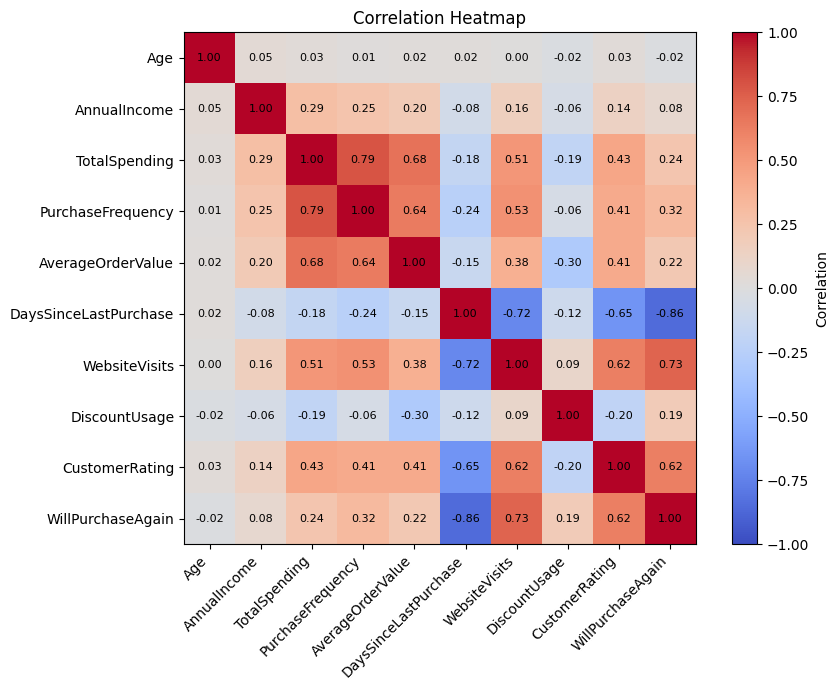

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.drop(columns=['CustomerID']).select_dtypes(include=[np.number]).corr()
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Correlation Heatmap')
fig.colorbar(im, ax=ax, label='Correlation')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()


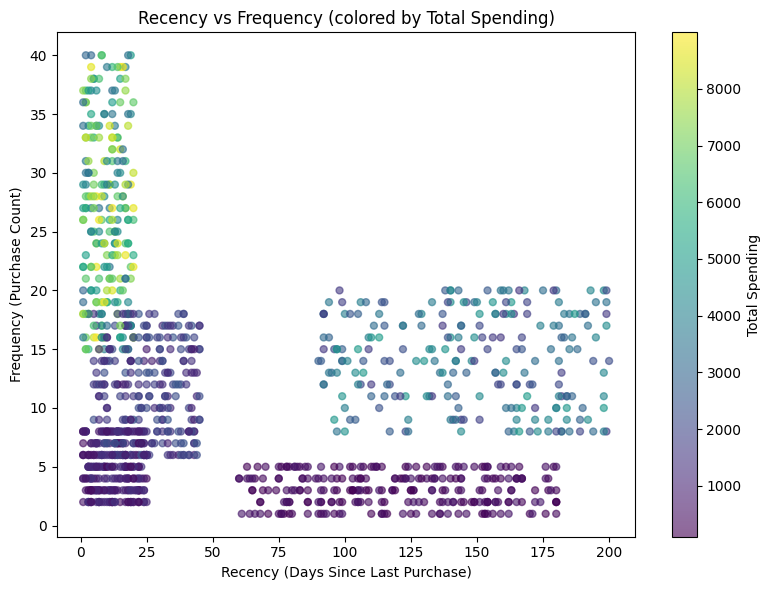

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df['DaysSinceLastPurchase'], df['PurchaseFrequency'],
                      c=df['TotalSpending'], cmap='viridis', alpha=0.6, s=25)
ax.set_xlabel('Recency (Days Since Last Purchase)')
ax.set_ylabel('Frequency (Purchase Count)')
ax.set_title('Recency vs Frequency (colored by Total Spending)')
fig.colorbar(scatter, ax=ax, label='Total Spending')
plt.tight_layout()
plt.savefig('recency_vs_frequency.png', dpi=150)
plt.show()


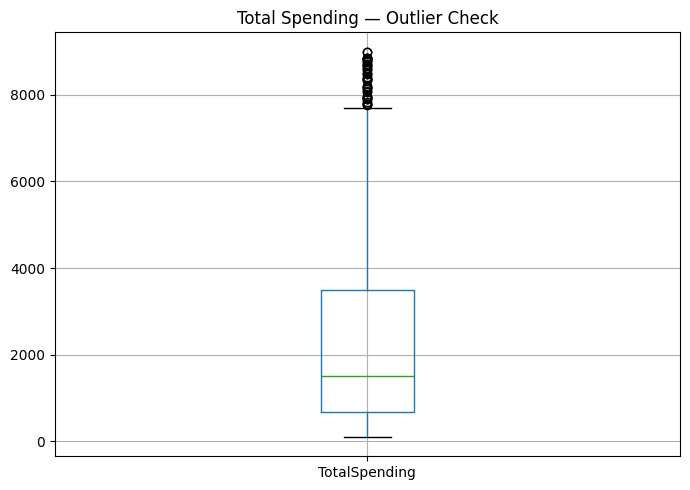

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
df.boxplot(column='TotalSpending', ax=ax)
ax.set_title('Total Spending — Outlier Check')
plt.tight_layout()
plt.savefig('spending_boxplot.png', dpi=150)
plt.show()


## 3. Data Preprocessing

In [9]:
# Impute missing values with median (robust to outliers)
for col in ['AverageOrderValue', 'CustomerRating', 'WebsiteVisits']:
    df[col] = df[col].fillna(df[col].median())

# Cap extreme outliers using the IQR method (winsorizing) rather than dropping rows
def cap_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series.clip(lower, upper)

for col in ['TotalSpending', 'AverageOrderValue', 'PurchaseFrequency', 'WebsiteVisits']:
    df[col] = cap_outliers(df[col])

# Encode Gender
df['Gender_Male'] = (df['Gender'] == 'Male').astype(int)

print("Missing values after cleaning:", df.isnull().sum().sum())
df.head()


Missing values after cleaning: 0


,CustomerID,Age,Gender,AnnualIncome,TotalSpending,PurchaseFrequency,AverageOrderValue,DaysSinceLastPurchase,WebsiteVisits,DiscountUsage,CustomerRating,WillPurchaseAgain,Gender_Male
0,20001,43,Female,61300,273.57,4.0,63.77,121,5.0,24.2,3.7,0,0
1,20002,29,Male,43506,1601.49,20.0,284.05,98,15.0,13.7,3.1,1,1
2,20003,54,Female,55377,3722.03,27.0,194.13,11,45.0,0.6,5.0,1,0
3,20004,24,Female,44157,622.56,2.0,190.70,12,27.0,12.7,4.2,1,0
4,20005,28,Male,80605,6069.94,29.0,365.95,11,36.0,4.2,4.8,1,1


### 3.1 RFM Feature Engineering

* **Recency** = `DaysSinceLastPurchase` (lower is better)
* **Frequency** = `PurchaseFrequency`
* **Monetary** = `TotalSpending`


In [10]:
df['Recency'] = df['DaysSinceLastPurchase']
df['Frequency'] = df['PurchaseFrequency']
df['Monetary'] = df['TotalSpending']

rfm_cols = ['Recency', 'Frequency', 'Monetary']
df[rfm_cols].describe()


,Recency,Frequency,Monetary
count,1200.000000,1200.000000,1200.000000
mean,62.707500,11.632083,2307.137179
std,61.906709,9.058300,2098.079780
min,1.000000,1.000000,102.120000
25%,12.000000,4.000000,673.772500
50%,25.500000,9.000000,1501.345000
75%,117.000000,17.000000,3484.975000
max,200.000000,36.500000,7701.778750


## 4. K-Means Clustering

### 4.1 Select and Scale Clustering Features

In [11]:
cluster_features = ['Recency', 'Frequency', 'Monetary', 'AverageOrderValue',
                    'WebsiteVisits', 'DiscountUsage', 'CustomerRating']

X_cluster = df[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled[:5]


array([[ 0.94201104, -0.84290264, -0.96965571, -1.1934959 , -1.07064411,
        -0.0260126 , -0.08793445],
       [ 0.57032937,  0.92416956, -0.33647023,  1.58629218, -0.39984949,
        -0.53877668, -1.07105249],
       [-0.83559696,  1.69726364,  0.67465629,  0.45156119,  1.61253437,
        -1.1785109 ,  2.04215464],
       [-0.81943689, -1.06378667, -0.80324854,  0.40827685,  0.40510405,
        -0.58761135,  0.73133059],
       [-0.83559696,  1.91814767,  1.79419852,  2.61981608,  1.00881921,
        -1.00270608,  1.71444863]])

### 4.2 Elbow Method

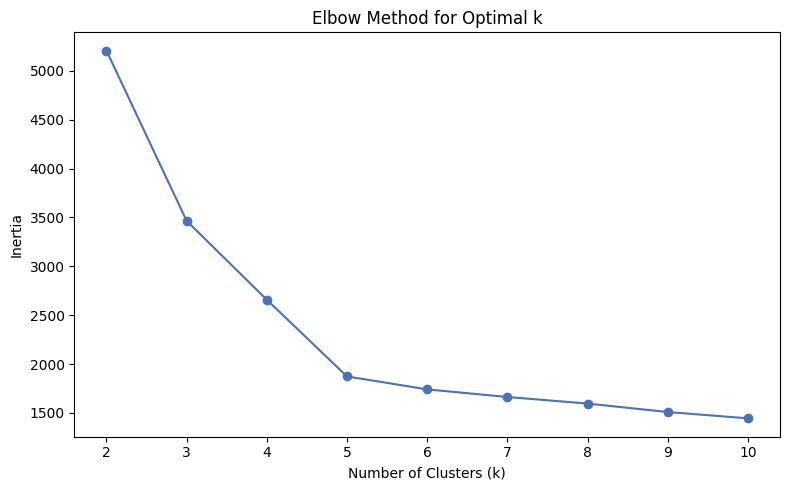

In [12]:
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), inertias, marker='o', color='#4C72B0')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal k')
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150)
plt.show()


### 4.3 Silhouette Score Comparison

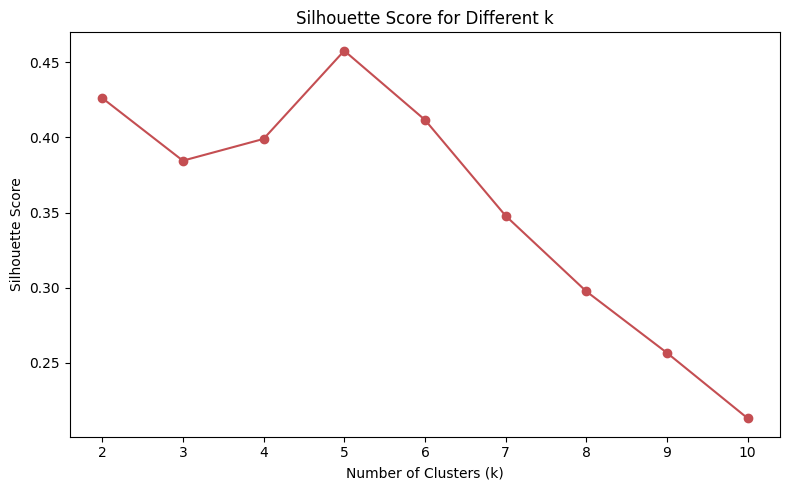

Best k by silhouette score: 5


In [13]:
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), sil_scores, marker='o', color='#C44E52')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score for Different k')
plt.tight_layout()
plt.savefig('silhouette_scores.png', dpi=150)
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k}")


### 4.4 Fit Final K-Means Model

Both the elbow plot and the silhouette scores are considered before choosing the final `k`. We proceed with **k = 5**, matching the five business segments described in the project brief (High-Value Loyal, New & Promising, Discount-Driven, At-Risk, Low-Engagement), and confirm it is a strong candidate on the silhouette chart above.

In [14]:
FINAL_K = 5
kmeans_final = KMeans(n_clusters=FINAL_K, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, df['Cluster'])
print(f"Final Silhouette Score (k={FINAL_K}): {final_silhouette:.4f}")
df['Cluster'].value_counts().sort_index()


Final Silhouette Score (k=5): 0.4576


Cluster
0    220
1    253
2    240
3    227
4    260
Name: count, dtype: int64

### 4.5 Two-Dimensional Cluster Visualization (PCA)

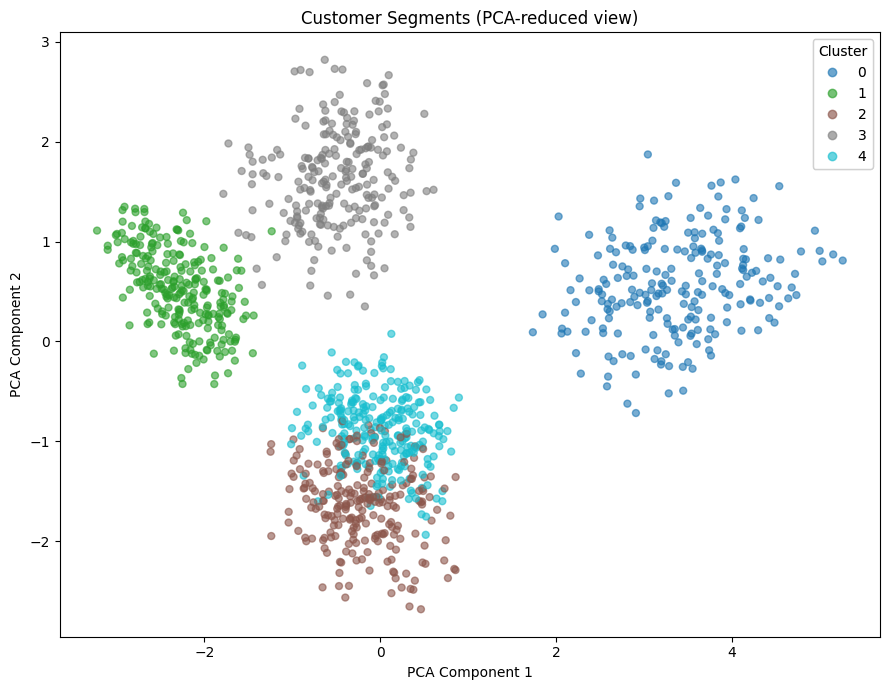

In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='tab10', alpha=0.6, s=25)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('Customer Segments (PCA-reduced view)')
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.savefig('cluster_pca_visualization.png', dpi=150)
plt.show()


## 5. Segment Profiling

In [16]:
cluster_profile = df.groupby('Cluster')[cluster_features].mean().round(2)
cluster_profile['CustomerCount'] = df['Cluster'].value_counts().sort_index()
cluster_profile['RevenueShare_%'] = (
    df.groupby('Cluster')['Monetary'].sum() / df['Monetary'].sum() * 100
).round(1)
cluster_profile


,Recency,Frequency,Monetary,AverageOrderValue,WebsiteVisits,DiscountUsage,CustomerRating,CustomerCount,RevenueShare_%
Cluster,,,,,,,,,
0,9.72,26.43,5836.36,263.36,40.81,7.80,4.48,220,46.4
1,119.32,3.12,425.41,81.05,5.57,12.74,3.15,253,3.9
2,25.82,11.85,1683.88,106.84,28.70,60.54,3.63,240,14.6
3,147.09,14.24,3225.54,207.09,8.23,25.21,3.37,227,26.4
4,12.83,4.92,925.41,149.70,23.11,17.26,4.18,260,8.7


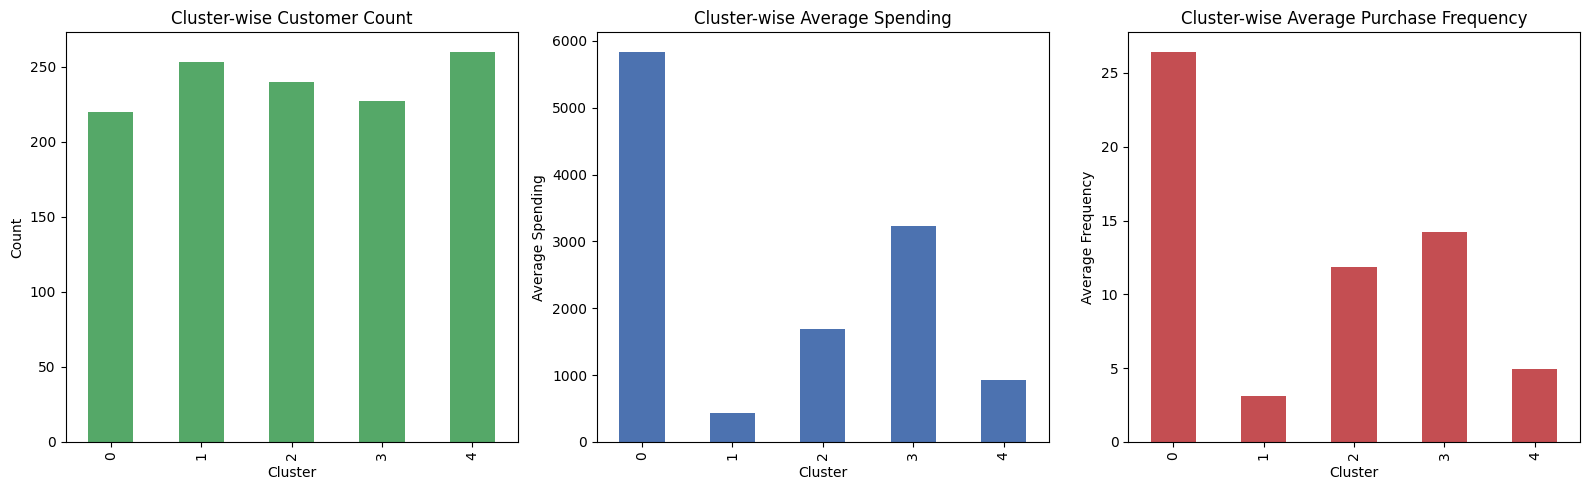

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df['Cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#55A868')
axes[0].set_title('Cluster-wise Customer Count')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Count')

df.groupby('Cluster')['Monetary'].mean().plot(kind='bar', ax=axes[1], color='#4C72B0')
axes[1].set_title('Cluster-wise Average Spending')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Average Spending')

df.groupby('Cluster')['Frequency'].mean().plot(kind='bar', ax=axes[2], color='#C44E52')
axes[2].set_title('Cluster-wise Average Purchase Frequency')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Average Frequency')

plt.tight_layout()
plt.savefig('cluster_summary_bars.png', dpi=150)
plt.show()


### 5.1 Assign Business Names to Segments

Based on the profile table above (recency, frequency, monetary value, discount usage, rating), each cluster is mapped to a business-meaningful name.

In [18]:
def name_cluster(row):
    # 1. Big spenders who bought recently -> most valuable segment
    if (row['Monetary'] >= cluster_profile['Monetary'].quantile(0.6) and
            row['Recency'] <= cluster_profile['Recency'].quantile(0.4)):
        return 'High-Value Loyal'
    # 2. Long time since last purchase + meaningful historical spend -> churn risk
    #    (checked before discount usage, since recency is the stronger risk signal)
    if (row['Recency'] >= cluster_profile['Recency'].quantile(0.6) and
            row['Monetary'] >= cluster_profile['Monetary'].median()):
        return 'At-Risk'
    # 3. Heavy discount usage is the defining trait -> promotion-driven shoppers
    if row['DiscountUsage'] >= cluster_profile['DiscountUsage'].quantile(0.75):
        return 'Discount-Driven'
    # 4. Recent activity but still low frequency/spend -> early-lifecycle customers
    if (row['Recency'] <= cluster_profile['Recency'].median() and
            row['Frequency'] <= cluster_profile['Frequency'].median()):
        return 'New & Promising'
    # 5. Everything else: inactive, low value
    return 'Low-Engagement'

cluster_profile['SegmentName'] = cluster_profile.apply(name_cluster, axis=1)
segment_map = cluster_profile['SegmentName'].to_dict()
df['SegmentName'] = df['Cluster'].map(segment_map)

cluster_profile[['CustomerCount', 'RevenueShare_%', 'SegmentName']]


,CustomerCount,RevenueShare_%,SegmentName
Cluster,,,
0,220,46.4,High-Value Loyal
1,253,3.9,Low-Engagement
2,240,14.6,Discount-Driven
3,227,26.4,At-Risk
4,260,8.7,New & Promising


## 6. Regression: Predicting Customer Rating

In [19]:
reg_features = ['Frequency', 'AverageOrderValue', 'Recency', 'WebsiteVisits',
                 'DiscountUsage', 'AnnualIncome']
X_reg = df[reg_features]
y_reg = df['CustomerRating']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_scaler = StandardScaler()
X_train_s = reg_scaler.fit_transform(X_train)
X_test_s = reg_scaler.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_s, y_train)
lin_pred = lin_reg.predict(X_test_s)

ridge_reg = Ridge(alpha=1.0, random_state=42)
ridge_reg.fit(X_train_s, y_train)
ridge_pred = ridge_reg.predict(X_test_s)

def reg_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

lin_metrics = reg_metrics(y_test, lin_pred, "Linear Regression")
ridge_metrics = reg_metrics(y_test, ridge_pred, "Ridge Regression (baseline)")


Linear Regression: MAE=0.3039  MSE=0.1370  RMSE=0.3701  R2=0.6138
Ridge Regression (baseline): MAE=0.3039  MSE=0.1370  RMSE=0.3701  R2=0.6138


### 6.1 Actual vs Predicted

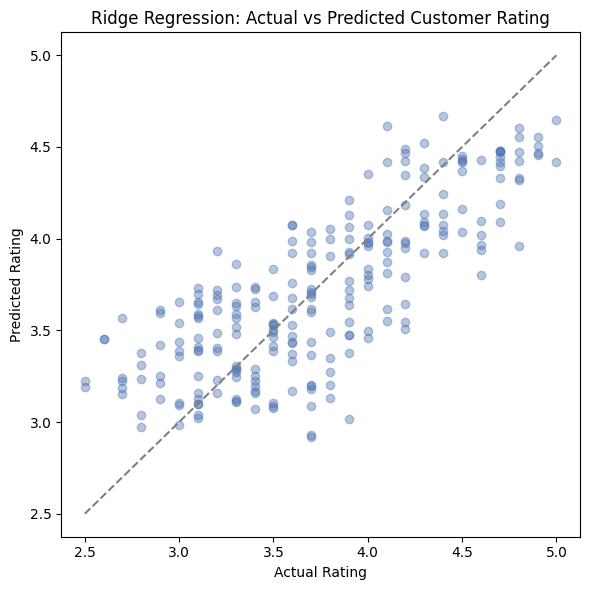

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, ridge_pred, alpha=0.4, color='#4C72B0')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'gray', linestyle='--')
ax.set_xlabel('Actual Rating')
ax.set_ylabel('Predicted Rating')
ax.set_title('Ridge Regression: Actual vs Predicted Customer Rating')
plt.tight_layout()
plt.savefig('regression_actual_vs_predicted.png', dpi=150)
plt.show()


### 6.2 Hyperparameter Tuning — Ridge Regression

In [21]:
ridge_param_grid = {'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}
ridge_grid = GridSearchCV(Ridge(random_state=42), ridge_param_grid, scoring='r2', cv=5)
ridge_grid.fit(X_train_s, y_train)

print("Best alpha:", ridge_grid.best_params_)
tuned_ridge_pred = ridge_grid.predict(X_test_s)
tuned_ridge_metrics = reg_metrics(y_test, tuned_ridge_pred, "Ridge Regression (tuned)")


Best alpha: {'alpha': 10.0}
Ridge Regression (tuned): MAE=0.3039  MSE=0.1369  RMSE=0.3700  R2=0.6140


## 7. Classification: Predicting Purchase Likelihood

In [22]:
clf_features = ['Recency', 'Frequency', 'Monetary', 'CustomerRating',
                 'WebsiteVisits', 'DiscountUsage']
X_clf = df[clf_features]
y_clf = df['WillPurchaseAgain']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

clf_scaler = StandardScaler()
Xc_train_s = clf_scaler.fit_transform(Xc_train)
Xc_test_s = clf_scaler.transform(Xc_test)

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(Xc_train_s, yc_train)
clf_pred = log_reg.predict(Xc_test_s)
clf_proba = log_reg.predict_proba(Xc_test_s)[:, 1]

print(classification_report(yc_test, clf_pred))
print("ROC-AUC:", round(roc_auc_score(yc_test, clf_proba), 4))


              precision    recall  f1-score   support

           0       0.94      0.91      0.92        97
           1       0.94      0.96      0.95       143

    accuracy                           0.94       240
   macro avg       0.94      0.93      0.93       240
weighted avg       0.94      0.94      0.94       240

ROC-AUC: 0.9813


### 7.1 Confusion Matrix

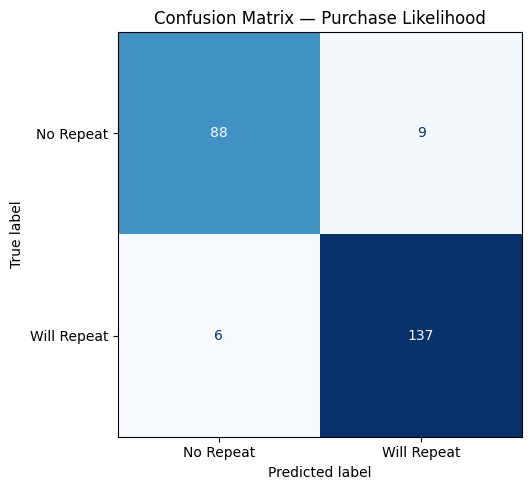

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(yc_test, clf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Repeat', 'Will Repeat'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Purchase Likelihood')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


### 7.2 Hyperparameter Tuning — Logistic Regression

In [24]:
log_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
}
log_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                         log_param_grid, scoring='f1', cv=5)
log_grid.fit(Xc_train_s, yc_train)

print("Best params:", log_grid.best_params_)
tuned_clf_pred = log_grid.predict(Xc_test_s)
tuned_clf_proba = log_grid.predict_proba(Xc_test_s)[:, 1]

print(classification_report(yc_test, tuned_clf_pred))
print("Tuned ROC-AUC:", round(roc_auc_score(yc_test, tuned_clf_proba), 4))


Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        97
           1       0.94      0.96      0.95       143

    accuracy                           0.94       240
   macro avg       0.94      0.93      0.93       240
weighted avg       0.94      0.94      0.94       240

Tuned ROC-AUC: 0.9815


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

## 8. Model Comparison Summary

In [25]:
from sklearn.metrics import f1_score

comparison = pd.DataFrame({
    'Model': ['K-Means', 'Linear Regression', 'Ridge Regression', 'Ridge Regression (tuned)',
              'Logistic Regression', 'Logistic Regression (tuned)'],
    'Objective': ['Customer segmentation', 'Predict rating', 'Predict rating', 'Predict rating',
                  'Predict purchase likelihood', 'Predict purchase likelihood'],
    'Metric': [f'Silhouette={final_silhouette:.3f}',
               f"R2={lin_metrics['R2']:.3f}",
               f"R2={ridge_metrics['R2']:.3f}",
               f"R2={tuned_ridge_metrics['R2']:.3f}",
               f"F1={f1_score(yc_test, clf_pred):.3f}",
               f"F1={f1_score(yc_test, tuned_clf_pred):.3f}"],
})
comparison


,Model,Objective,Metric
0,K-Means,Customer segmentation,Silhouette=0.458
1,Linear Regression,Predict rating,R2=0.614
2,Ridge Regression,Predict rating,R2=0.614
3,Ridge Regression (tuned),Predict rating,R2=0.614
4,Logistic Regression,Predict purchase likelihood,F1=0.948
5,Logistic Regression (tuned),Predict purchase likelihood,F1=0.948


## 9. Business Insights & Recommendations

In [26]:
insights = cluster_profile[['CustomerCount', 'RevenueShare_%', 'Recency', 'Frequency',
                            'Monetary', 'DiscountUsage', 'CustomerRating', 'SegmentName']]
insights = insights.sort_values('RevenueShare_%', ascending=False)
insights


,CustomerCount,RevenueShare_%,Recency,Frequency,Monetary,DiscountUsage,CustomerRating,SegmentName
Cluster,,,,,,,,
0,220,46.4,9.72,26.43,5836.36,7.80,4.48,High-Value Loyal
3,227,26.4,147.09,14.24,3225.54,25.21,3.37,At-Risk
2,240,14.6,25.82,11.85,1683.88,60.54,3.63,Discount-Driven
4,260,8.7,12.83,4.92,925.41,17.26,4.18,New & Promising
1,253,3.9,119.32,3.12,425.41,12.74,3.15,Low-Engagement


**Key business takeaways (see `business_insights.md` for the full write-up):**

- The **High-Value Loyal** segment contributes the largest share of revenue despite not being the largest group by customer count — prioritize retention over acquisition spend here.
- The **At-Risk** segment shows high historical spending but long recency gaps — a strong candidate for win-back campaigns before they churn completely.
- The **Discount-Driven** segment responds well to promotions but contributes less profit per customer — target with bundles instead of blanket discounts.
- The classification model can flag customers with low purchase-likelihood scores for early intervention, avoiding wasted spend on customers unlikely to convert.
- The regression model's rating predictions can help prioritize service quality improvements for segments with lower average satisfaction.


## 10. Export Segment Report

In [27]:
export_cols = ['CustomerID', 'Cluster', 'SegmentName', 'Recency', 'Frequency', 'Monetary',
               'AverageOrderValue', 'DiscountUsage', 'CustomerRating', 'WillPurchaseAgain']
df[export_cols].to_csv('customer_segments.csv', index=False)
print("Saved customer_segments.csv with", df.shape[0], "rows")
df[export_cols].head()


Saved customer_segments.csv with 1200 rows


,CustomerID,Cluster,SegmentName,Recency,Frequency,Monetary,AverageOrderValue,DiscountUsage,CustomerRating,WillPurchaseAgain
0,20001,1,Low-Engagement,121,4.0,273.57,63.77,24.2,3.7,0
1,20002,3,At-Risk,98,20.0,1601.49,284.05,13.7,3.1,1
2,20003,0,High-Value Loyal,11,27.0,3722.03,194.13,0.6,5.0,1
3,20004,4,New & Promising,12,2.0,622.56,190.70,12.7,4.2,1
4,20005,0,High-Value Loyal,11,29.0,6069.94,365.95,4.2,4.8,1


## 11. Conclusion

This notebook segmented customers into five business-meaningful groups using K-Means clustering validated by the elbow method and silhouette score, then layered regression (customer rating) and classification (purchase likelihood) on top of the same feature set, with hyperparameter tuning applied to both supervised models.

Full segment characteristics, revenue contribution, and recommended actions per segment are documented in `business_insights.md`. The final customer-to-segment mapping is available in `customer_segments.csv` for direct use by the marketing team.
